In [19]:
#Day 7: Testing Ball Detection Across Multiple Images**

In [20]:
!pip install -q ultralytics

In [21]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [47]:
def detect_ball(image_path, lower, upper):

 #load image
  img = cv2.imread(image_path)
  # convert to HSV
  hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)

  # create mask
  mask = cv2.inRange(hsv,lower,upper)

  # fig,axes = plt.subplots(1,2,figsize =(12,5))
  # #showing Original
  # axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
  # axes[0].set_title("Original")

  # #showing Masked image
  # axes[1].imshow(mask,cmap="gray")
  # axes[1].set_title("Masked")
  # plt.show()

  # find contours
  contour_exter,hierarchy = cv2.findContours(
      mask,
      cv2.RETR_EXTERNAL,
      cv2.CHAIN_APPROX_SIMPLE
  )
  # filter by area + circularity
  best_ratio =0
  best_contour = None
  best_radius = None
  best_center = None
  for contour in contour_exter:
    area = cv2.contourArea(contour)
    if area > 100:
      center, radius = cv2.minEnclosingCircle(contour)
      circle_area = np.pi * radius**2
      ratio = area / circle_area
      #print(area, radius, ratio)
      if ratio > best_ratio:
        best_ratio = ratio
        best_contour = contour
        best_radius = radius
        best_center = centerest_center = center

  # print(best_ratio,best_radius)


  # draw result
  img_copy= img.copy()
  center_int = (int(best_center[0]),int(best_center[1]))
  radius_int = int(best_radius)
  cv2.circle(img_copy,center_int,radius_int,(0,255,0),4)

  # return or display the image
  plt.imshow(cv2.cvtColor(img_copy,cv2.COLOR_BGR2RGB))
  plt.show()


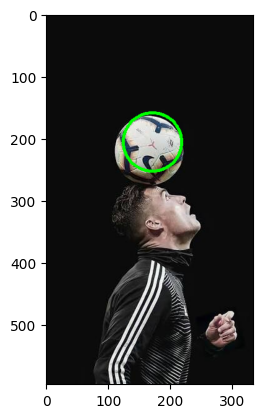

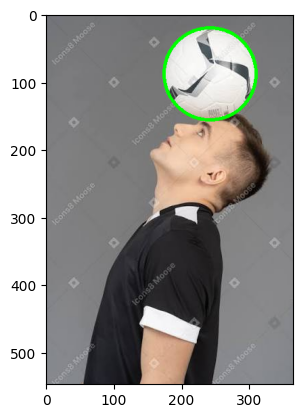

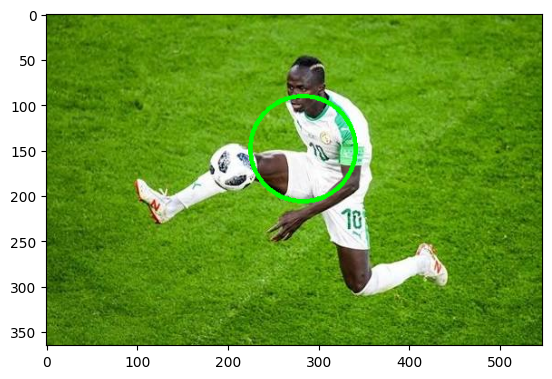

In [48]:
#function variables
lower_int = np.array([0, 0, 180])
upper_int = np.array([179, 60, 255])


detection = detect_ball("/content/Ronaldo ball",lower_int,upper_int)
detection_1 = detect_ball("/content/randomball",lower_int,upper_int)
detection_2 = detect_ball("/content/Sadio ball",lower_int,upper_int)



In [ ]:
# now it detects fully this pic

# Nice — clean detection, ratio 0.88, the highest you've gotten across all 4 images.
#  This image had good separation: gray background, black jersey, no competing
#  white objects — exactly the condition where color+shape detection performs at its best.

# So your final Day 7 scoreboard across 4 real images:

# Image	Result	Why
# 1 (original)	Success (0.74)	Clean color separation
# 2 (Sadio, white kit)	Failed	Ball and jersey share white color
# 3 (shadowed ball)	Success (0.585)	Large distinct blob, survived partial shadow
# 4 (studio photo)	Failed	Background + subject merged into one giant blob
# 5 (gray bg, black kit)	Success (0.88)	Best case: strong color contrast, no competing white
# That's a genuinely solid, evidence-backed conclusion for Day 7: classical
# color+shape detection is highly conditional on scene contrast —
# it works well in ~2 out of 5 realistic conditions, and fails whenever another
#  object shares the target's color or brightness range. That instability is exactly
#  why the roadmap moves to YOLO next, which detects based on learned visual
#  patterns rather than pixel color.